# Шығын функциялары — Практикалық тапсырма


Бұл тапсырмада шығын функцияларын нөлден өзіңіз жазасыз, туындыларын есептейсіз, нақты деректерде үлгілерді үйретесіз және нәтижелерді талдайсыз.

Барлық `___` бос орындарды толтыру керек. Әр бос орынның үстінде `# Кеңес:` жолы бар.

##  Кітапханаларды жүктеу

Бұл ұяшықты өзгертпей іске қосыңыз.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['font.size'] = 11
np.random.seed(42)

print('Кітапханалар жүктелді.')

Кітапханалар жүктелді.


## Бөлім 1. Теориялық анықтамалар

**Мақсат:** Тапсырма барысында қолданылатын барлық формулаларды бір жерде қарастыру.

### Регрессия шығын функциялары

**MSE — Орташа квадраттық қате:**

$$\mathcal{L}_{MSE} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2$$

Туындысы: $\dfrac{\partial \mathcal{L}}{\partial \hat{y}} = \dfrac{2}{m}(\hat{y} - y)$

**RMSE — Квадрат түбірі:**

$$\mathcal{L}_{RMSE} = \sqrt{\mathcal{L}_{MSE}}$$

**MAE — Орташа абсолюттік қате:**

$$\mathcal{L}_{MAE} = \frac{1}{m}\sum_{i=1}^{m}|\hat{y}^{(i)} - y^{(i)}|$$

Туындысы: $\dfrac{\partial \mathcal{L}}{\partial \hat{y}} = \dfrac{1}{m}\text{sign}(\hat{y} - y)$

**Huber Loss ($\delta$ параметрімен):**

$$\mathcal{L}_{\delta} = \frac{1}{m}\sum_{i=1}^{m} \begin{cases} \frac{1}{2}(\hat{y}^{(i)}-y^{(i)})^2 & |\hat{y}^{(i)}-y^{(i)}| \leq \delta \\ \delta\left(|\hat{y}^{(i)}-y^{(i)}| - \frac{\delta}{2}\right) & \text{басқаша} \end{cases}$$

### Классификация шығын функциялары

**Sigmoid (Logistic) функциясы:**

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad \sigma'(z) = \sigma(z)(1 - \sigma(z))$$

**Binary Cross-Entropy (BCE):**

$$\mathcal{L}_{BCE} = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log\hat{y}^{(i)} + (1-y^{(i)})\log(1-\hat{y}^{(i)})\right]$$

Туындысы ($z = wx+b$ бойынша): $\dfrac{\partial \mathcal{L}}{\partial z} = \hat{y} - y$

**Hinge Loss ($y \in \{-1, +1\}$):**

$$\mathcal{L}_{Hinge} = \frac{1}{m}\sum_{i=1}^{m}\max\left(0,\ 1 - y^{(i)}\hat{y}^{(i)}\right)$$

## Бөлім 2. Регрессия шығын функцияларын іске асыру

**Мақсат:** MSE, RMSE, MAE және Huber функцияларын нөлден жазып, олардың мінез-құлқын зерттеу.

### 2.1 MSE функциясы

MSE квадраттық жазалау арқылы үлкен қателерді күшті жазалайды. Аномальды мәндерге өте сезімтал.

In [10]:
def mse(y_true, y_pred):
    """
    Орташа квадраттық қате.
    MSE = (1/m) * sum((y_pred - y_true)^2)

    Параметрлер:
        y_true : array — нақты мәндер
        y_pred : array — болжамдар
    Қайтарады:
        float — MSE мәні
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Кеңес: np.mean() және квадраттауды қолданыңыз

    return np.mean((y_pred - y_true)**2)

In [11]:
# --- ТЕКСЕРУ ---
y_true_test = np.array([1.0, 2.0, 3.0, 4.0])
y_pred_test = np.array([1.5, 2.5, 2.5, 3.5])

result = mse(y_true_test, y_pred_test)
expected = 0.25

assert abs(result - expected) < 1e-9, f"Қате: күтілген {expected}, алынған {result}"
print(f'MSE = {result:.4f}  (күтілген: {expected})')
print('Тексеру ОТКЕН.')

MSE = 0.2500  (күтілген: 0.25)
Тексеру ОТКЕН.


### 2.2 RMSE және MAE функциялары

In [22]:
def rmse(y_true, y_pred):
    """
    Квадрат түбіріндегі орташа квадраттық қате.
    RMSE = sqrt(MSE)
    Артықшылығы: y-мен бірдей өлшем бірлігінде болады.
    """
    # Кеңес: жоғарыда жазған mse() функциясын шақырыңыз, np.sqrt() қолданыңыз
    return np.sqrt(mse(y_true, y_pred))


def mae(y_true, y_pred):
    """
    Орташа абсолюттік қате.
    MAE = (1/m) * sum(|y_pred - y_true|)
    Аномальды мәндерге MSE-ге қарағанда төзімдірек.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Кеңес: np.abs() және np.mean() қолданыңыз
    return np.mean(np.abs(y_pred - y_true))

In [23]:
# --- ТЕКСЕРУ ---
assert abs(rmse(y_true_test, y_pred_test) - 0.5) < 1e-9, "RMSE қате!"
assert abs(mae(y_true_test, y_pred_test) - 0.5) < 1e-9, "MAE қате!"

print(f'RMSE = {rmse(y_true_test, y_pred_test):.4f}  (күтілген: 0.5000)')
print(f'MAE  = {mae(y_true_test, y_pred_test):.4f}  (күтілген: 0.5000)')
print('Тексерулер ОТКЕН.')

RMSE = 0.5000  (күтілген: 0.5000)
MAE  = 0.5000  (күтілген: 0.5000)
Тексерулер ОТКЕН.


### 2.3 Huber Loss функциясы

Huber Loss MSE мен MAE арасындағы компромис: кішкентай қателерде MSE тәрізді (дөңес, дифференцияланатын), үлкен қателерде MAE тәрізді (аномалияларға төзімді).

In [27]:
def huber_loss(y_true, y_pred, delta=1.0):
    """
    Huber Loss функциясы.

    Формула:
        |қате| <= delta болса:  0.5 * қате^2
        |қате|  > delta болса:  delta * (|қате| - 0.5 * delta)

    Параметрлер:
        y_true : array
        y_pred : array
        delta  : float — шек мән (default: 1.0)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Кеңес: алдымен |қате|-ны есептеңіз
    residual = np.abs(y_pred - y_true)


    # Кеңес: np.where(шарт, иә_мән, жоқ_мән) қолданыңыз
    # |residual| <= delta болса: 0.5 * residual**2
    # |residual| >  delta болса: delta * (|residual| - 0.5 * delta)
    loss = np.where(
        residual <=delta,
        0.5 *residual**2,
        delta * (residual - 0.5 * delta  )
    )
    return np.mean(loss)

In [28]:
# --- ТЕКСЕРУ ---
# delta=1.0, қате=[0.5, 0.5, 0.5, 0.5] — барлығы <= delta, демек 0.5*0.5^2=0.125
assert abs(huber_loss(y_true_test, y_pred_test, delta=1.0) - 0.125) < 1e-9, "Huber қате!"

# delta=0.3, қате=0.5 > 0.3, демек 0.3*(0.5-0.15)=0.105
assert abs(huber_loss(y_true_test, y_pred_test, delta=0.3) - 0.105) < 1e-9, "Huber (delta=0.3) қате!"

print(f'Huber (delta=1.0) = {huber_loss(y_true_test, y_pred_test, delta=1.0):.4f}  (күтілген: 0.1250)')
print(f'Huber (delta=0.3) = {huber_loss(y_true_test, y_pred_test, delta=0.3):.4f}  (күтілген: 0.1050)')
print('Тексерулер ОТКЕН.')

Huber (delta=1.0) = 0.1250  (күтілген: 0.1250)
Huber (delta=0.3) = 0.1050  (күтілген: 0.1050)
Тексерулер ОТКЕН.


### 2.4 Аномальды мәндерге сезімталдық эксперименті

**Мақсат:** MSE мен MAE-ның аномальды мәндерге (outlier) реакциясын көзбен көру.

In [29]:
# Базалық деректер
y_base = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_base_pred = np.array([1.1, 2.2, 2.9, 3.8, 5.1])

# Аномалиясы бар деректер — соңғы мән 5.0 орнына 50.0
y_outlier_pred = np.array([1.1, 2.2, 2.9, 3.8, 50.0])

# TODO: Аномалиясыз және аномалиямен MSE мен MAE мәндерін есептеңіз
# Кеңес: жоғарыда жазған mse() және mae() функцияларын қолданыңыз

mse_normal  = mse(y_base, y_base_pred)
mse_outlier = mse(y_base, y_outlier_pred)
mae_normal  = mae(y_base, y_base_pred)
mae_outlier = mae(y_base, y_outlier_pred)

print('Аномальды мән болса:')
print(f'  MSE: {mse_normal:.4f} → {mse_outlier:.2f}  ({mse_outlier/mse_normal:.0f}x өсті)')
print(f'  MAE: {mae_normal:.4f} → {mae_outlier:.2f}  ({mae_outlier/mae_normal:.0f}x өсті)')
print()
print('Қорытынды: MSE аномальды мәнді күшті жазалайды (квадраттау),\n'
      '           MAE салыстырмалы аз жазалайды (абсолюттік мән).')

Аномальды мән болса:
  MSE: 0.0220 → 405.02  (18410x өсті)
  MAE: 0.1400 → 9.12  (65x өсті)

Қорытынды: MSE аномальды мәнді күшті жазалайды (квадраттау),
           MAE салыстырмалы аз жазалайды (абсолюттік мән).


<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1203/1956083543.py:7: SyntaxWarning: invalid escape sequence '\h'
  axes[0].plot(err, err**2,          'steelblue',  lw=2.5, label='MSE: $(\hat{y}-y)^2$')
/tmp/ipykernel_1203/1956083543.py:8: SyntaxWarning: invalid escape sequence '\h'
  axes[0].plot(err, np.abs(err),     'darkorange', lw=2.5, label='MAE: $|\hat{y}-y|$')
/tmp/ipykernel_1203/1956083543.py:10: SyntaxWarning: invalid escape sequence '\d'
  axes[0].plot(err, huber_vals, 'green', lw=2.5, linestyle='--', label='Huber ($\delta$=1)')
/tmp/ipykernel_1203/1956083543.py:11: SyntaxWarning: invalid escape sequence '\h'
 

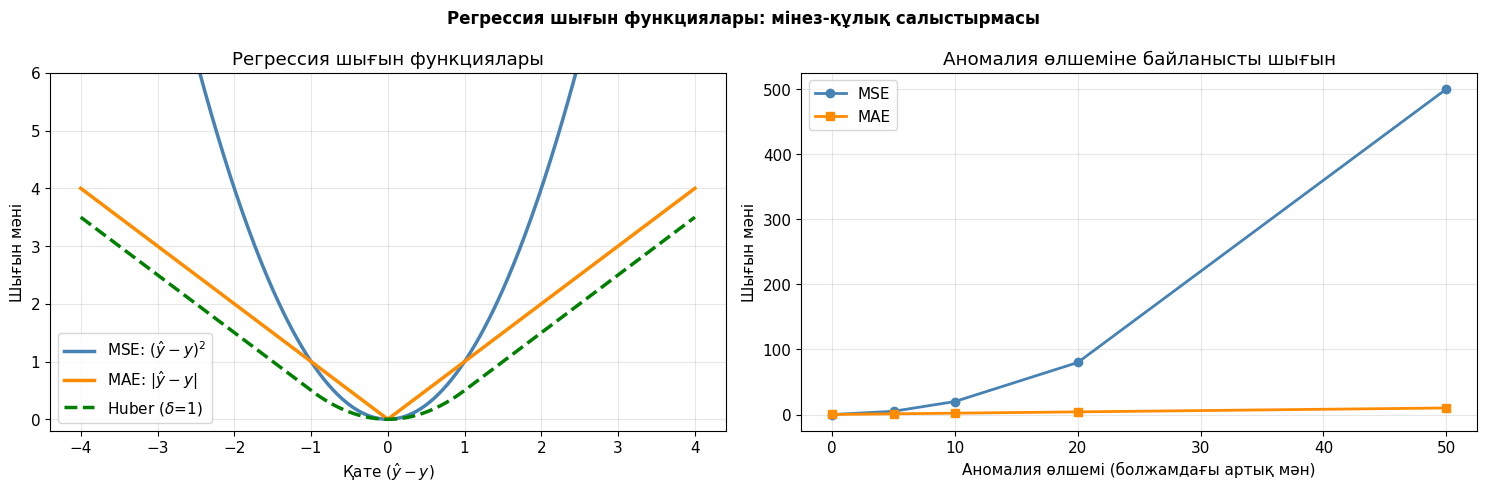

In [31]:
# Шығын функцияларын визуализациялау
err = np.linspace(-4, 4, 400)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Сол: шығын функциялары
axes[0].plot(err, err**2,          'steelblue',  lw=2.5, label='MSE: $(\hat{y}-y)^2$')
axes[0].plot(err, np.abs(err),     'darkorange', lw=2.5, label='MAE: $|\hat{y}-y|$')
huber_vals = np.where(np.abs(err)<=1.0, 0.5*err**2, 1.0*(np.abs(err)-0.5))
axes[0].plot(err, huber_vals, 'green', lw=2.5, linestyle='--', label='Huber ($\delta$=1)')
axes[0].set_xlabel('Қате $(\hat{y} - y)$')
axes[0].set_ylabel('Шығын мәні')
axes[0].set_title('Регрессия шығын функциялары')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(-0.2, 6)

# Оң: аномальды мәнге реакция
outlier_sizes = [0, 5, 10, 20, 50]
mse_vals = [mse(y_base, y_base_pred[:-1].tolist() + [5.0 + s]) for s in outlier_sizes]
mae_vals = [mae(y_base, y_base_pred[:-1].tolist() + [5.0 + s]) for s in outlier_sizes]

axes[1].plot(outlier_sizes, mse_vals, 'o-', color='steelblue',  lw=2, label='MSE')
axes[1].plot(outlier_sizes, mae_vals, 's-', color='darkorange', lw=2, label='MAE')
axes[1].set_xlabel('Аномалия өлшемі (болжамдағы артық мән)')
axes[1].set_ylabel('Шығын мәні')
axes[1].set_title('Аномалия өлшеміне байланысты шығын')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Регрессия шығын функциялары: мінез-құлық салыстырмасы',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Бөлім 3. Регрессия шығын функцияларының туындылары

**Мақсат:** Градиенттік түсу үшін қажетті туындыларды іске асыру және сандық жуықтаумен тексеру.

Градиенттік түсу итерациясы:

$$\theta \leftarrow \theta - \eta \cdot \frac{\partial \mathcal{L}}{\partial \theta}$$

Сандық туынды (тексеру үшін): $f'(x) \approx \dfrac{f(x+h) - f(x-h)}{2h}$

In [33]:
def mse_gradient(y_true, y_pred):
    """
    MSE функциясының y_pred бойынша туындысы.
    dL/d(y_pred) = 2/m * (y_pred - y_true)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    m = len(y_true)
    # Кеңес: формулада 2, бөлгіш m, айырым (y_pred - y_true)
    return (2 / m) * (y_pred - y_true)


def mae_gradient(y_true, y_pred):
    """
    MAE функциясының y_pred бойынша туындысы.
    dL/d(y_pred) = 1/m * sign(y_pred - y_true)

    Ескертпе: нөлде туынды анықталмаған, np.sign(0) = 0 деп аламыз.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    m = len(y_true)
    # Кеңес: np.sign() функциясын қолданыңыз
    return (1 / m) * np.sign(y_pred - y_true)

In [34]:
# Сандық тексеру — аналитикалық туынды дұрыс па?
def numerical_gradient(loss_fn, y_true, y_pred, h=1e-5):
    """Орталық айырым формуласымен сандық туынды."""
    grad = np.zeros_like(y_pred, dtype=float)
    for i in range(len(y_pred)):
        y_plus  = y_pred.copy(); y_plus[i]  += h
        y_minus = y_pred.copy(); y_minus[i] -= h
        grad[i] = (loss_fn(y_true, y_plus) - loss_fn(y_true, y_minus)) / (2 * h)
    return grad

y_t = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_p = np.array([1.3, 2.5, 2.8, 4.2, 5.1])

grad_mse_analytic = mse_gradient(y_t, y_p)
grad_mse_numeric  = numerical_gradient(mse, y_t, y_p)

grad_mae_analytic = mae_gradient(y_t, y_p)
grad_mae_numeric  = numerical_gradient(mae, y_t, y_p)

print('MSE туындысы:')
print(f'  Аналитикалық: {grad_mse_analytic.round(6)}')
print(f'  Сандық:       {grad_mse_numeric.round(6)}')
print(f'  Макс. айырым: {np.max(np.abs(grad_mse_analytic - grad_mse_numeric)):.2e}')

print('\nMAE туындысы:')
print(f'  Аналитикалық: {grad_mae_analytic.round(6)}')
print(f'  Сандық:       {grad_mae_numeric.round(6)}')
print(f'  Макс. айырым: {np.max(np.abs(grad_mae_analytic - grad_mae_numeric)):.2e}')

assert np.max(np.abs(grad_mse_analytic - grad_mse_numeric)) < 1e-5, "MSE туынды қате!"
print('\nТексерулер ОТКЕН — туындылар дұрыс.')

MSE туындысы:
  Аналитикалық: [ 0.12  0.2  -0.08  0.08  0.04]
  Сандық:       [ 0.12  0.2  -0.08  0.08  0.04]
  Макс. айырым: 2.56e-12

MAE туындысы:
  Аналитикалық: [ 0.2  0.2 -0.2  0.2  0.2]
  Сандық:       [ 0.2  0.2 -0.2  0.2  0.2]
  Макс. айырым: 5.35e-12

Тексерулер ОТКЕН — туындылар дұрыс.


## Бөлім 4. Классификация шығын функциялары

**Мақсат:** Sigmoid, Binary Cross-Entropy және Hinge Loss функцияларын іске асыру.

### 4.1 Sigmoid функциясы

Sigmoid сызықты шығысты $(0, 1)$ аралығындағы ықтималдыққа айналдырады:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Туындысы: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ — тізбек ережесін оңайлатады.

In [38]:
def sigmoid(z):
    """
    Sigmoid (Logistic) функциясы.
    sigma(z) = 1 / (1 + exp(-z))

    Ескертпе: np.clip(z, -500, 500) арқылы сандық тасуды болдырмаңыз.
    """
    # Кеңес: np.exp() және np.clip() қолданыңыз
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(z):
    """
    Sigmoid туындысы.
    sigma'(z) = sigma(z) * (1 - sigma(z))
    """
    # Кеңес: жоғарыда жазған sigmoid() функциясын шақырыңыз
    s = sigmoid(z)
    return s * (1 - s)

In [39]:
# --- ТЕКСЕРУ ---
assert abs(sigmoid(0)   - 0.5)    < 1e-9, "sigmoid(0) = 0.5 болуы керек!"
assert abs(sigmoid(100) - 1.0)    < 1e-6, "sigmoid(100) ≈ 1.0 болуы керек!"
assert abs(sigmoid(-100)- 0.0)    < 1e-6, "sigmoid(-100) ≈ 0.0 болуы керек!"
assert abs(sigmoid_derivative(0)  - 0.25) < 1e-9, "sigma'(0) = 0.25 болуы керек!"

z_test = np.array([-2, -1, 0, 1, 2])
print(f'sigmoid({z_test}) = {sigmoid(z_test).round(4)}')
print(f"sigma'({z_test})  = {sigmoid_derivative(z_test).round(4)}")
print('Тексерулер ОТКЕН.')

sigmoid([-2 -1  0  1  2]) = [0.1192 0.2689 0.5    0.7311 0.8808]
sigma'([-2 -1  0  1  2])  = [0.105  0.1966 0.25   0.1966 0.105 ]
Тексерулер ОТКЕН.


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1203/1741321581.py:6: SyntaxWarning: invalid escape sequence '\s'
  axes[0].plot(z_range, sigmoid(z_range), 'steelblue', lw=2.5, label='$\sigma(z)$')
/tmp/ipykernel_1203/1741321581.py:7: SyntaxWarning: invalid escape sequence '\s'
  axes[0].axhline(0.5, color='gray', linesty

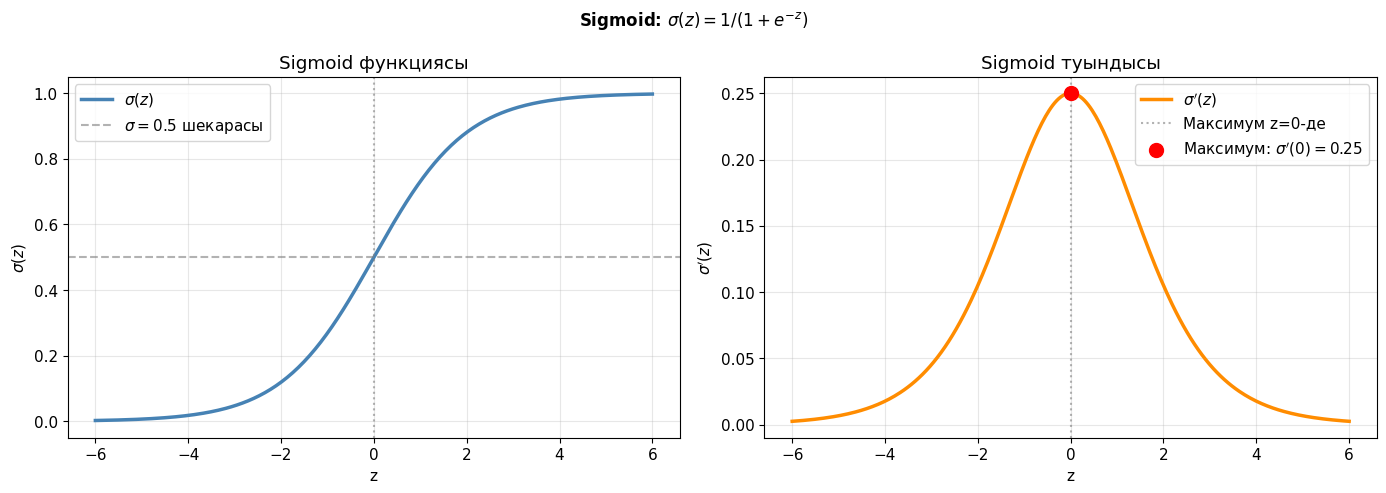

In [40]:
# Sigmoid және оның туындысын визуализациялау
z_range = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(z_range, sigmoid(z_range), 'steelblue', lw=2.5, label='$\sigma(z)$')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='$\sigma=0.5$ шекарасы')
axes[0].axvline(0.0, color='gray', linestyle=':', alpha=0.6)
axes[0].set_xlabel('z')
axes[0].set_ylabel('$\sigma(z)$')
axes[0].set_title('Sigmoid функциясы')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(-0.05, 1.05)

axes[1].plot(z_range, sigmoid_derivative(z_range), 'darkorange', lw=2.5, label="$\sigma'(z)$")
axes[1].axvline(0, color='gray', linestyle=':', alpha=0.6, label='Максимум z=0-де')
axes[1].scatter([0], [0.25], color='red', s=100, zorder=5, label="Максимум: $\sigma'(0)=0.25$")
axes[1].set_xlabel('z')
axes[1].set_ylabel("$\sigma'(z)$")
axes[1].set_title('Sigmoid туындысы')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Sigmoid: $\sigma(z) = 1/(1+e^{-z})$', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Binary Cross-Entropy (BCE)

BCE дұрыс класстың логарифмдік ықтималдығын жазалайды. $y=1$ болса $-\log\hat{y}$, $y=0$ болса $-\log(1-\hat{y})$ есептеледі.

In [43]:
def binary_cross_entropy(y_true, y_pred, eps=1e-12):
    """
    Бинарлы крест-энтропия шығын функциясы.

    Формула:
        BCE = -(1/m) * sum(y * log(y_hat) + (1-y) * log(1-y_hat))

    Параметрлер:
        y_true : array — нақты белгілер {0, 1}
        y_pred : array — болжам ықтималдықтары (0, 1) аралығында
        eps    : float — log(0) жоқ үшін кішкентай мән
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    # Кеңес: np.clip() арқылы y_pred-ті (eps, 1-eps) аралығына шектеңіз
    y_pred =  np.clip(y_pred, eps, 1 - eps)

    # Кеңес: формуланы тікелей іске асырыңыз, np.log() қолданыңыз
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [44]:
# --- ТЕКСЕРУ ---
y_t_c = np.array([1.0, 0.0, 1.0, 0.0])

# Мінсіз болжам: BCE ≈ 0
y_perfect = np.array([0.9999, 0.0001, 0.9999, 0.0001])
bce_perfect = binary_cross_entropy(y_t_c, y_perfect)

# Кездейсоқ болжам: BCE ≈ ln(2) ≈ 0.693
y_random = np.array([0.5, 0.5, 0.5, 0.5])
bce_random = binary_cross_entropy(y_t_c, y_random)

assert bce_perfect < 0.01, "Мінсіз болжам үшін BCE өте кіші болуы керек!"
assert abs(bce_random - np.log(2)) < 0.001, "Кездейсоқ болжам үшін BCE ≈ ln(2) болуы керек!"

print(f'Мінсіз болжам BCE = {bce_perfect:.6f}  (күтілген: ≈0)')
print(f'Кездейсоқ болжам BCE = {bce_random:.6f}  (күтілген: ln(2)≈{np.log(2):.6f})')
print('Тексерулер ОТКЕН.')

Мінсіз болжам BCE = 0.000100  (күтілген: ≈0)
Кездейсоқ болжам BCE = 0.693147  (күтілген: ln(2)≈0.693147)
Тексерулер ОТКЕН.


<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1203/906371983.py:5: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(y_hat_range, -np.log(y_hat_range),       'steelblue',  lw=2.5, label='y=1: $-\log(\hat{y})$')
/tmp/ipykernel_1203/906371983.py:6: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(y_hat_range, -np.log(1 - y_hat_range),   'darkorange', lw=2.5, label='y=0: $-\log(1-\hat{y})$')
/tmp/ipykernel_1203/906371983.py:8: SyntaxWarning: invalid escape sequence '\h'
  ax.set_xlabel('Болжам ықтималдығы $\hat{y}$')


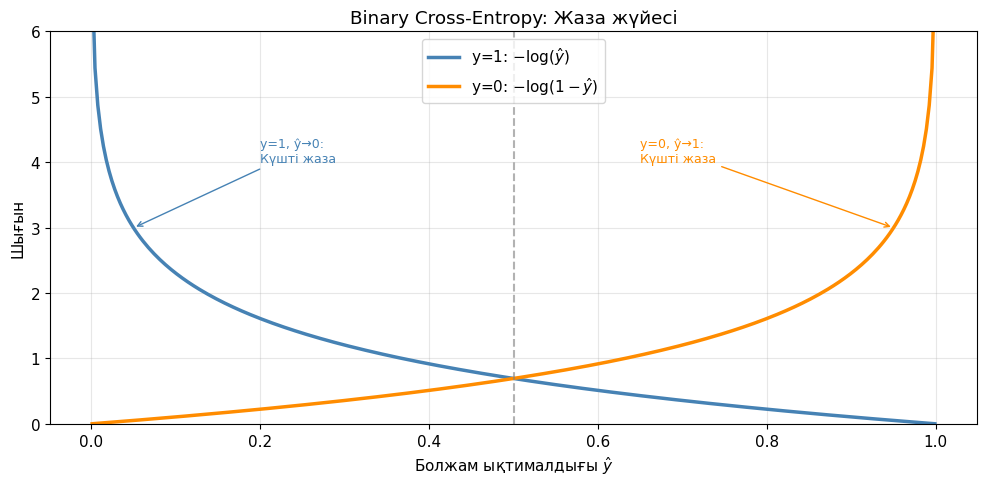

In [45]:
# BCE-ны визуализациялау
y_hat_range = np.linspace(0.001, 0.999, 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(y_hat_range, -np.log(y_hat_range),       'steelblue',  lw=2.5, label='y=1: $-\log(\hat{y})$')
ax.plot(y_hat_range, -np.log(1 - y_hat_range),   'darkorange', lw=2.5, label='y=0: $-\log(1-\hat{y})$')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6)
ax.set_xlabel('Болжам ықтималдығы $\hat{y}$')
ax.set_ylabel('Шығын')
ax.set_title('Binary Cross-Entropy: Жаза жүйесі')
ax.legend()
ax.set_ylim(0, 6)
ax.grid(alpha=0.3)

# Аннотациялар
ax.annotate('y=1, ŷ→0:\nКүшті жаза',
            xy=(0.05, -np.log(0.05)), xytext=(0.2, 4),
            arrowprops=dict(arrowstyle='->', color='steelblue'),
            color='steelblue', fontsize=9)
ax.annotate('y=0, ŷ→1:\nКүшті жаза',
            xy=(0.95, -np.log(0.05)), xytext=(0.65, 4),
            arrowprops=dict(arrowstyle='->', color='darkorange'),
            color='darkorange', fontsize=9)

plt.tight_layout()
plt.show()

### 4.3 Hinge Loss (SVM шығын функциясы)

Hinge Loss белгілерді $\{-1, +1\}$ түрінде пайдаланады. Маржа $\geq 1$ болса — шығын нөл.

In [46]:
def hinge_loss(y_true, y_pred):
    """
    Hinge Loss функциясы (SVM).

    Формула: (1/m) * sum(max(0, 1 - y_true * y_pred))

    Параметрлер:
        y_true : array — нақты белгілер {-1, +1} форматында
        y_pred : array — болжамдар (сызықты шығыс, ықтималдық емес)
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    # Кеңес: np.maximum(0, ...) қолданыңыз
    return np.mean(np.maximum(0, 1 - y_true * y_pred))

In [47]:
# --- ТЕКСЕРУ ---
# y=+1, y_hat=+2: margin = 1*2=2 >= 1 → шығын=0
# y=-1, y_hat=-2: margin = -1*(-2)=2 >= 1 → шығын=0
y_perfect_h = np.array([1., -1.,  1., -1.])
y_conf_h    = np.array([2., -2.,  2., -2.])  # сенімді болжам
assert abs(hinge_loss(y_perfect_h, y_conf_h) - 0.0) < 1e-9, "Hinge: сенімді болжам шығыны 0 болуы керек!"

# y=+1, y_hat=0.5: margin = 0.5 < 1 → шығын=0.5
y_t_h = np.array([1., -1.])
y_p_h = np.array([0.5, -0.5])
# max(0, 1-1*0.5) + max(0, 1-(-1)*(-0.5)) = 0.5 + 0.5 = 1.0, орташасы 0.5
assert abs(hinge_loss(y_t_h, y_p_h) - 0.5) < 1e-9, f"Hinge: {hinge_loss(y_t_h, y_p_h)} ≠ 0.5"

print(f'Сенімді болжам (margin=2): {hinge_loss(y_perfect_h, y_conf_h):.4f}  (күтілген: 0)')
print(f'Сенімсіз болжам (margin=0.5): {hinge_loss(y_t_h, y_p_h):.4f}  (күтілген: 0.5)')
print('Тексерулер ОТКЕН.')

Сенімді болжам (margin=2): 0.0000  (күтілген: 0)
Сенімсіз болжам (margin=0.5): 0.5000  (күтілген: 0.5)
Тексерулер ОТКЕН.


## Бөлім 5. Нақты деректерде регрессия — Diabetes деректері

**Мақсат:** Diabetes деректерінде градиенттік түсумен сызықты регрессияны үйретіп, MSE мен MAE нәтижелерін салыстыру.

**Diabetes деректер жиынтығы:** 442 науқастың медициналық деректері. Мақсат: аурудың бір жыл ішіндегі дамуын болжау (сандық мән, 25–346 аралығында).

Биз екі белгі қолданамыз: `bmi` (дене салмақ индексі) және `s5` (сарысу триглицеридтері).

In [48]:
# Деректерді жүктеу
diabetes = load_diabetes()
X_raw = diabetes.data[:, [2, 8]]  # bmi, s5
y_raw = diabetes.target

print(f'Деректер: {X_raw.shape[0]} науқас, {X_raw.shape[1]} белгі')
print(f'Мақсат (прогрессия): [{y_raw.min():.0f}, {y_raw.max():.0f}], орташа={y_raw.mean():.1f}')

# Деректерді бөлу және масштабтау
X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)
sc = StandardScaler()
X_tr = sc.fit_transform(X_tr)
X_te = sc.transform(X_te)

print(f'Үйрету: {X_tr.shape[0]}, Тест: {X_te.shape[0]}')

Деректер: 442 науқас, 2 белгі
Мақсат (прогрессия): [25, 346], орташа=152.1
Үйрету: 353, Тест: 89


In [49]:
class LinearRegressionGD:
    """
    Градиенттік түсу арқылы сызықты регрессия.
    Шығын функциясы MSE немесе MAE таңдалады.
    """

    def __init__(self, loss='mse', lr=0.01, n_epochs=500):
        self.loss_name = loss
        self.lr        = lr
        self.n_epochs  = n_epochs
        self.w         = None
        self.b         = None
        self.history   = []

    def _loss_and_grad(self, X, y, y_hat):
        m = len(y)
        if self.loss_name == 'mse':
            loss_val = mse(y, y_hat)
            # dL/d(y_hat) = 2*(y_hat - y)/m
            dL_dyhat = 2 * (y_hat - y) / m
        else:  # mae
            loss_val = mae(y, y_hat)
            # dL/d(y_hat) = sign(y_hat - y)/m
            dL_dyhat = np.sign(y_hat - y) / m

        # Тізбек ережесі: y_hat = X@w + b
        # dL/dw = X^T @ dL/dy_hat
        # dL/db = sum(dL/dy_hat)
        dw = X.T @ dL_dyhat
        db = dL_dyhat.sum()
        return loss_val, dw, db

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        self.history = []

        for _ in range(self.n_epochs):
            y_hat = X @ self.w + self.b
            loss_val, dw, db = self._loss_and_grad(X, y, y_hat)
            self.w -= self.lr * dw
            self.b -= self.lr * db
            self.history.append(loss_val)
        return self

    def predict(self, X):
        return X @ self.w + self.b

print('LinearRegressionGD класы дайын.')

LinearRegressionGD класы дайын.


In [50]:
# TODO: MSE шығын функциясымен үлгіні үйретіңіз
# Кеңес: LinearRegressionGD(loss='mse', lr=0.05, n_epochs=500)
model_mse = LinearRegressionGD(loss='mse', lr=0.05, n_epochs=500)
model_mse.fit(X_tr, y_tr)   # Кеңес: .fit() шақырыңыз

# TODO: MAE шығын функциясымен үлгіні үйретіңіз
# Кеңес: LinearRegressionGD(loss='mae', lr=0.05, n_epochs=500)
model_mae = LinearRegressionGD(loss='mae', lr=0.05, n_epochs=500)
model_mae.fit(X_tr, y_tr)

# TODO: Тест жиынтығы үшін болжамдар жасаңыз
# Кеңес: .predict() шақырыңыз
y_pred_mse = model_mse.predict(X_te)
y_pred_mae = model_mae.predict(X_te)

print('MSE үлгісі:')
print(f'  Тест MSE  = {mse(y_te, y_pred_mse):.2f}')
print(f'  Тест RMSE = {rmse(y_te, y_pred_mse):.2f}')
print(f'  Тест MAE  = {mae(y_te, y_pred_mse):.2f}')

print('\nMAE үлгісі:')
print(f'  Тест MSE  = {mse(y_te, y_pred_mae):.2f}')
print(f'  Тест RMSE = {rmse(y_te, y_pred_mae):.2f}')
print(f'  Тест MAE  = {mae(y_te, y_pred_mae):.2f}')

MSE үлгісі:
  Тест MSE  = 2901.84
  Тест RMSE = 53.87
  Тест MAE  = 43.99

MAE үлгісі:
  Тест MSE  = 19884.82
  Тест RMSE = 141.01
  Тест MAE  = 120.78


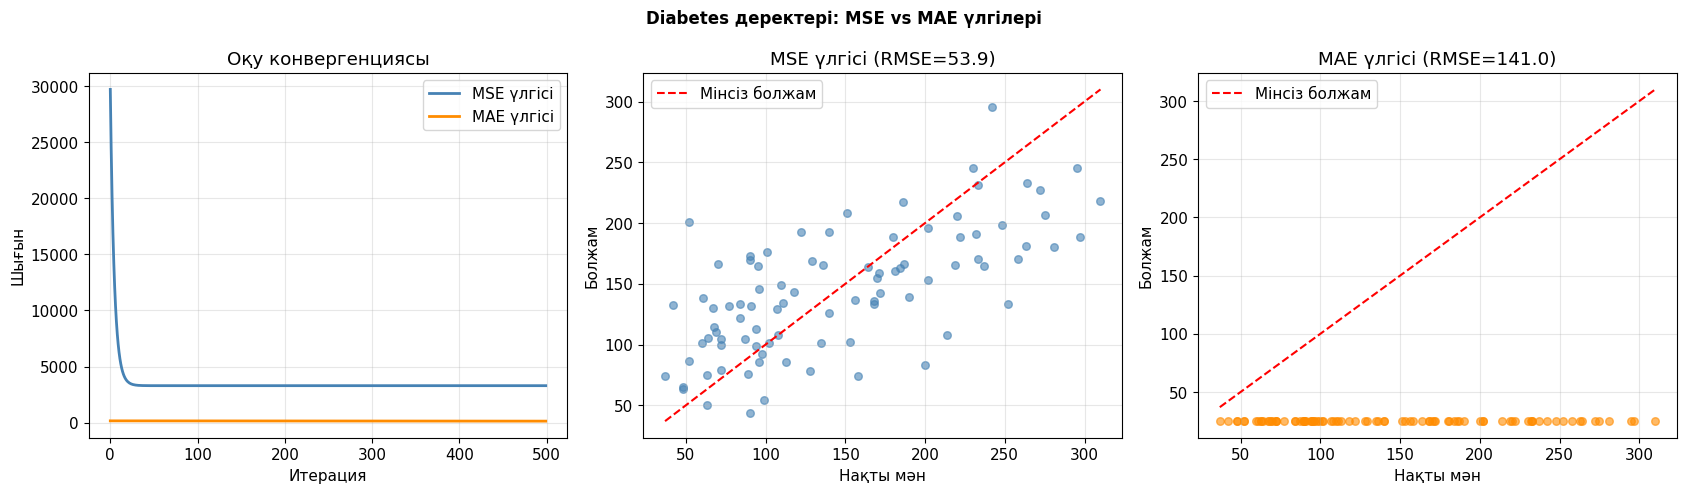

In [51]:
# Нәтижелерді визуализациялау
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Конвергенция
axes[0].plot(model_mse.history, 'steelblue', lw=2, label='MSE үлгісі')
axes[0].plot(model_mae.history, 'darkorange', lw=2, label='MAE үлгісі')
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('Шығын')
axes[0].set_title('Оқу конвергенциясы')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Нақты vs болжамдар — MSE
axes[1].scatter(y_te, y_pred_mse, alpha=0.6, s=30, color='steelblue')
lims = [min(y_te.min(), y_pred_mse.min()), max(y_te.max(), y_pred_mse.max())]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Мінсіз болжам')
axes[1].set_xlabel('Нақты мән')
axes[1].set_ylabel('Болжам')
axes[1].set_title(f'MSE үлгісі (RMSE={rmse(y_te, y_pred_mse):.1f})')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Нақты vs болжамдар — MAE
axes[2].scatter(y_te, y_pred_mae, alpha=0.6, s=30, color='darkorange')
axes[2].plot(lims, lims, 'r--', lw=1.5, label='Мінсіз болжам')
axes[2].set_xlabel('Нақты мән')
axes[2].set_ylabel('Болжам')
axes[2].set_title(f'MAE үлгісі (RMSE={rmse(y_te, y_pred_mae):.1f})')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Diabetes деректері: MSE vs MAE үлгілері', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Бөлім 6. Нақты деректерде классификация — Breast Cancer деректері

**Мақсат:** BCE шығын функциясымен логистикалық регрессияны нөлден үйретіп, Hinge Loss-пен салыстыру.

**Breast Cancer Wisconsin деректері:** 569 ісік үлгісі. Мақсат: қатерлі (0) немесе қатерсіз (1) екенін классификациялау.

Алғашқы 5 белгі: `mean radius`, `mean texture`, `mean perimeter`, `mean area`, `mean smoothness`.

In [52]:
# Деректерді жүктеу
cancer = load_breast_cancer()
X_c_raw = cancer.data[:, :5]
y_c     = cancer.target.astype(float)  # 0=қатерлі, 1=қатерсіз

print(f'Деректер: {X_c_raw.shape[0]} үлгі, {X_c_raw.shape[1]} белгі')
print(f'Класстар: 0=қатерлі ({(y_c==0).sum()}), 1=қатерсіз ({(y_c==1).sum()})')

X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(
    X_c_raw, y_c, test_size=0.2, random_state=42, stratify=y_c
)
sc_c = StandardScaler()
X_c_tr = sc_c.fit_transform(X_c_tr)
X_c_te = sc_c.transform(X_c_te)

print(f'Үйрету: {X_c_tr.shape[0]}, Тест: {X_c_te.shape[0]}')

Деректер: 569 үлгі, 5 белгі
Класстар: 0=қатерлі (212), 1=қатерсіз (357)
Үйрету: 455, Тест: 114


In [53]:
class LogisticRegressionBCE:
    """
    Binary Cross-Entropy шығын функциясымен логистикалық регрессия.
    """

    def __init__(self, lr=0.1, n_epochs=300):
        self.lr       = lr
        self.n_epochs = n_epochs
        self.w        = None
        self.b        = None
        self.history  = []

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        self.history = []

        for _ in range(self.n_epochs):
            z    = X @ self.w + self.b
            yhat = sigmoid(z)                      # ықтималдық болжам
            loss = binary_cross_entropy(y, yhat)   # BCE шығыны

            # Туынды: dL/dz = (yhat - y) / m
            # (BCE + sigmoid тізбек ережесінен шыққан жеңілдетілген нәтиже)
            dz = (yhat - y) / m
            dw = X.T @ dz
            db = dz.sum()

            self.w -= self.lr * dw
            self.b -= self.lr * db
            self.history.append(loss)
        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print('LogisticRegressionBCE класы дайын.')

LogisticRegressionBCE класы дайын.


In [54]:
# TODO: BCE үлгісін үйретіңіз
# Кеңес: LogisticRegressionBCE(lr=0.1, n_epochs=300)
model_bce = LogisticRegressionBCE(lr=0.1, n_epochs=300)
model_bce.fit(X_c_tr, y_c_tr)

# TODO: Тест жиынтығы үшін класс болжамдарын жасаңыз
# Кеңес: .predict()
y_c_pred = model_bce.predict(X_c_te)
accuracy_bce = np.mean(y_c_pred == y_c_te)

# TODO: Дәлдікті есептеңіз
# Кеңес: np.mean(y_c_pred == y_c_te)


print(f'BCE үлгісінің тест дәлдігі: {accuracy_bce*100:.2f}%')
print(f'Соңғы BCE шығыны: {model_bce.history[-1]:.6f}')

BCE үлгісінің тест дәлдігі: 86.84%
Соңғы BCE шығыны: 0.163428


In [58]:
# Hinge Loss классификаторы — y белгілерін {0,1}-ден {-1,+1}-ге аударамыз
class LinearSVMHinge:
    """
    Hinge Loss шығын функциясымен сызықты классификатор (SGD-SVM).
    """

    def __init__(self, lr=0.01, n_epochs=300, lam=0.001):
        self.lr       = lr
        self.n_epochs = n_epochs
        self.lam      = lam   # L2 реттеу коэффициенті
        self.w        = None
        self.b        = None
        self.history  = []

    def fit(self, X, y):
        # y: {0,1} → {-1,+1}
        y_h = np.where(y == 0, -1.0, 1.0)
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        self.history = []

        for _ in range(self.n_epochs):
            scores = X @ self.w + self.b
            margin = y_h * scores

            loss = hinge_loss(y_h, scores) + self.lam * np.sum(self.w**2)
            self.history.append(loss)

            # Hinge gradient + L2 реттеу
            mask = (margin < 1).astype(float)
            dw = (-X.T @ (y_h * mask)) / m + 2 * self.lam * self.w
            db = (-y_h * mask).mean()

            self.w -= self.lr * dw
            self.b -= self.lr * db
        return self

    def predict(self, X):
        scores = X @ self.w + self.b
        return (scores >= 0).astype(int)

print('LinearSVMHinge класы дайын.')

LinearSVMHinge класы дайын.


In [60]:
# TODO: Hinge үлгісін үйретіңіз
# Кеңес: LinearSVMHinge(lr=0.01, n_epochs=300, lam=0.001)
model_hinge = LinearSVMHinge(lr=0.01, n_epochs=300, lam=0.001)
model_hinge.fit(X_c_tr, y_c_tr)
# TODO: Тест болжамын жасаңыз


# TODO: Дәлдікті есептеңіз
y_hinge_pred = model_hinge.predict(X_c_te)
accuracy_hinge = np.mean(y_hinge_pred == y_c_te)
print(f'BCE   үлгісінің тест дәлдігі: {accuracy_bce*100:.2f}%')
print(f'Hinge үлгісінің тест дәлдігі: {accuracy_hinge*100:.2f}%')

BCE   үлгісінің тест дәлдігі: 86.84%
Hinge үлгісінің тест дәлдігі: 88.60%


<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1203/2886448478.py:18: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_xlabel('Болжам ықтималдығы $\hat{y}$')


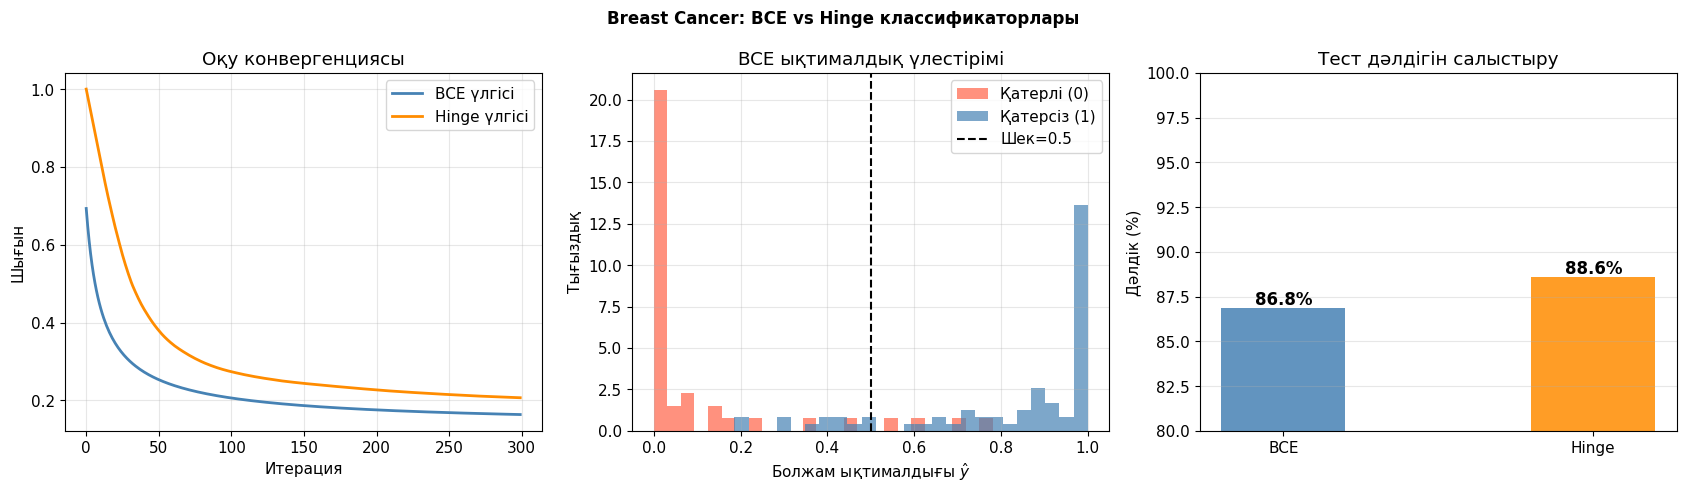

In [61]:
# Нәтижелерді визуализациялау
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Конвергенция
axes[0].plot(model_bce.history,   'steelblue',  lw=2, label='BCE үлгісі')
axes[0].plot(model_hinge.history, 'darkorange', lw=2, label='Hinge үлгісі')
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('Шығын')
axes[0].set_title('Оқу конвергенциясы')
axes[0].legend()
axes[0].grid(alpha=0.3)

# BCE ROC-тәрізді болжам ықтималдықтары
proba = model_bce.predict_proba(X_c_te)
axes[1].hist(proba[y_c_te==0], bins=25, alpha=0.7, color='tomato',    label='Қатерлі (0)', density=True)
axes[1].hist(proba[y_c_te==1], bins=25, alpha=0.7, color='steelblue', label='Қатерсіз (1)', density=True)
axes[1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Шек=0.5')
axes[1].set_xlabel('Болжам ықтималдығы $\hat{y}$')
axes[1].set_ylabel('Тығыздық')
axes[1].set_title('BCE ықтималдық үлестірімі')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Салыстырмалы дәлдік
names = ['BCE', 'Hinge']
accs  = [accuracy_bce, accuracy_hinge]
bars  = axes[2].bar(names, [a*100 for a in accs],
                    color=['steelblue', 'darkorange'], alpha=0.85, width=0.4)
axes[2].set_ylim(80, 100)
axes[2].set_ylabel('Дәлдік (%)')
axes[2].set_title('Тест дәлдігін салыстыру')
axes[2].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{acc*100:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Breast Cancer: BCE vs Hinge классификаторлары', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Бөлім 7. Шығын функциялары мен оқу жылдамдығын зерттеу

**Мақсат:** Оқу жылдамдығының конвергенцияға әсерін және шығын функциялары арасындағы айырмашылықты эксперимент арқылы зерттеу.

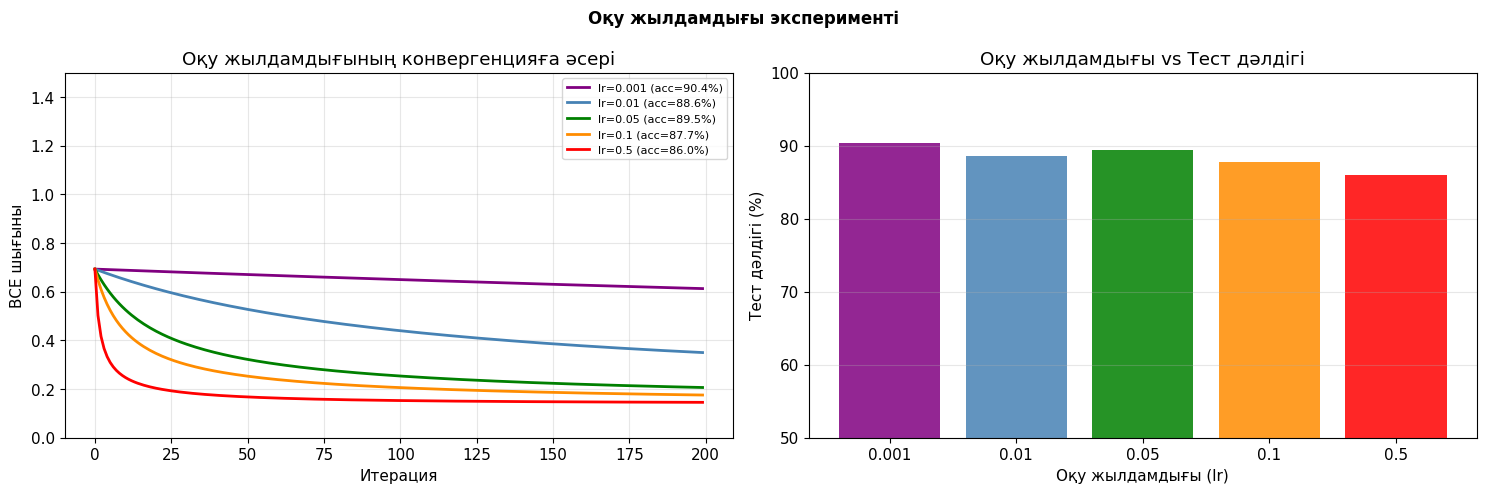

Ең жоғары дәлдік:
  lr=0.001: 90.35%


In [63]:
# TODO: Әртүрлі оқу жылдамдықтарын тексеріңіз
# [0.001, 0.01, 0.05, 0.1, 0.5] мәндерін сынап, конвергенцияны графикте салыстырыңыз

lr_values = [0.001, 0.01, 0.05, 0.1, 0.5]
lr_colors = ['purple', 'steelblue', 'green', 'darkorange', 'red']
lr_results = {}

for lr_val in lr_values:
    m = LogisticRegressionBCE(lr=lr_val, n_epochs=200)
    m.fit(X_c_tr, y_c_tr)
    acc = np.mean(m.predict(X_c_te) == y_c_te)
    lr_results[lr_val] = (m.history, acc)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for lr_val, color in zip(lr_values, lr_colors):
    history, acc = lr_results[lr_val]
    axes[0].plot(history, color=color, lw=2, label=f'lr={lr_val} (acc={acc*100:.1f}%)')

axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('BCE шығыны')
axes[0].set_title('Оқу жылдамдығының конвергенцияға әсері')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.5)
axes[0].grid(alpha=0.3)

accs_all = [lr_results[lr][1]*100 for lr in lr_values]
axes[1].bar([str(lr) for lr in lr_values], accs_all,
            color=lr_colors, alpha=0.85)
axes[1].set_xlabel('Оқу жылдамдығы (lr)')
axes[1].set_ylabel('Тест дәлдігі (%)')
axes[1].set_title('Оқу жылдамдығы vs Тест дәлдігі')
axes[1].set_ylim(50, 100)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Оқу жылдамдығы эксперименті', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Ең жоғары дәлдік:')
best_lr = max(lr_results, key=lambda k: lr_results[k][1])
print(f'  lr={best_lr}: {lr_results[best_lr][1]*100:.2f}%')

## Бөлім 8. Жинақтама салыстыру

**Мақсат:** Тапсырмада меңгерілген барлық шығын функцияларының нәтижелерін бір жерде жинақтап шығару.

In [64]:
print('=' * 65)
print('ШЫҒЫН ФУНКЦИЯЛАРЫ — ТАПСЫРМА НӘТИЖЕЛЕРІ')
print('=' * 65)

print('\nРЕГРЕССИЯ (Diabetes деректері):')
print(f'  MSE үлгісі — Тест RMSE: {rmse(y_te, y_pred_mse):.2f}')
print(f'  MAE үлгісі — Тест RMSE: {rmse(y_te, y_pred_mae):.2f}')

print('\nКЛАССИФИКАЦИЯ (Breast Cancer деректері):')
print(f'  BCE   үлгісі — Тест дәлдігі: {accuracy_bce*100:.2f}%')
print(f'  Hinge үлгісі — Тест дәлдігі: {accuracy_hinge*100:.2f}%')

print('\nОҚУ ЖЫЛДАМДЫҒЫ ЭКСПЕРИМЕНТІ:')
for lr_val in lr_values:
    acc = lr_results[lr_val][1]
    print(f'  lr={lr_val:5.3f} → дәлдік: {acc*100:.1f}%')

print('\n' + '=' * 65)

ШЫҒЫН ФУНКЦИЯЛАРЫ — ТАПСЫРМА НӘТИЖЕЛЕРІ

РЕГРЕССИЯ (Diabetes деректері):
  MSE үлгісі — Тест RMSE: 53.87
  MAE үлгісі — Тест RMSE: 141.01

КЛАССИФИКАЦИЯ (Breast Cancer деректері):
  BCE   үлгісі — Тест дәлдігі: 86.84%
  Hinge үлгісі — Тест дәлдігі: 88.60%

ОҚУ ЖЫЛДАМДЫҒЫ ЭКСПЕРИМЕНТІ:
  lr=0.001 → дәлдік: 90.4%
  lr=0.010 → дәлдік: 88.6%
  lr=0.050 → дәлдік: 89.5%
  lr=0.100 → дәлдік: 87.7%
  lr=0.500 → дәлдік: 86.0%



## Бөлім 9. Қорытынды сұрақтар

**Мақсат:** Тапсырмада меңгерілген білімді тұжырымдап бекіту.

### Сұрақ 1

Аномальды мәндер (outliers) бар деректерде MSE-ге қарағанда MAE немесе Huber Loss не үшін тиімдірек? Тапсырмадағы эксперименттен мысал келтіріңіз.

**Жауап:**

*(Осы жерге жауабыңызды жазыңыз)*

### Сұрақ 2

Binary Cross-Entropy формуласындағы логарифм нені өлшейді? $y=1$ болғанда $\hat{y} \to 0$ жақындаса шығын неге $+\infty$-ге жақындайды?

**Жауап:**

*(Осы жерге жауабыңызды жазыңыз)*

### Сұрақ 3

Hinge Loss-та "маржа" $\geq 1$ болса шығын нөл болады. Бұл BCE шығын функциясынан қандай принципиалды айырмашылық? Қай жағдайда Hinge Loss тиімдірек?

**Жауап:**

*(Осы жерге жауабыңызды жазыңыз)*

### Сұрақ 4

Оқу жылдамдығы экспериментінде ($lr = 0.001$ бастап $lr = 0.5$-ке дейін) не байқадыңыз? Оңтайлы lr мәні неге бастапқы немесе соңғы мән емес?

**Жауап:**

*(Осы жерге жауабыңызды жазыңыз)*